In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
pio.renderers.default="svg"

In [253]:
raw_dataset=pd.read_csv("Zomato Chennai Listing 2020.csv")
raw_dataset

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [254]:
raw_dataset.shape

(12032, 12)

In [255]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [256]:
raw_dataset.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [257]:
raw_dataset.isnull().sum()

Zomato URL                  0
Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [258]:
raw_dataset[raw_dataset['Dining Rating'].isnull()]

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
6,https://www.zomato.com/chennai/bai-veetu-kalya...,Bai Veetu Kalyanam,"1/187, Thalambur Road, Navallur, Chennai",Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,NaN,Does not offer Dining,4.3,1061,['Home Delivery']
77,https://www.zomato.com/chennai/al-dhareeq-beef...,Al Dhareeq Beef Biriyani,"64/A, 162, Sivan Kovil South Street, Kodambak...",Kodambakkam,['Biryani'],['Beef Biryani'],300.0,NaN,Does not offer Dining,3.9,19600,['Home Delivery']
106,https://www.zomato.com/chennai/twilight-take-o...,Twilight Take Out,"1, Park Side Street, Lake Area, Nungambakkam,...",Nungambakkam,"['North Indian', ' Chinese', ' Rolls', ' Conti...","['Club Sandwich', ' Chicken Tikka Roll', ' Chi...",350.0,NaN,Does not offer Dining,4.0,11200,"['Home Delivery', 'Free Parking']"
107,https://www.zomato.com/chennai/the-red-box-ann...,The Red Box,"Flat 51/C, Shanthi Colony Main Road, Anna Nag...",Anna Nagar West,['Chinese'],"['Noodle', ' Chilli Chicken Gravy', ' Dragon C...",200.0,NaN,Does not offer Dining,4.2,11500,['Home Delivery']
114,https://www.zomato.com/chennai/charminar-biriy...,Charminar Biriyani Centre,"91, Dr. Besant Road, Near Meesapet Market, Ro...",Royapettah,"['Biryani', ' North Indian']","['Chicken Biryani', ' Bread Halwa', ' Brinjal ...",300.0,NaN,Does not offer Dining,3.9,652,"['Home Delivery', 'Standing Tables']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [259]:
#raw_dataset=raw_dataset.dropna(subset=['Delivery Rating'])

In [260]:
#raw_dataset=raw_dataset.dropna(subset=['Dining Rating'])

In [261]:
raw_dataset['Delivery Rating'].isnull().sum()

np.int64(5851)

In [262]:
raw_dataset['Dining Rating'].isnull().sum()

np.int64(5351)

In [263]:
raw_dataset

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [264]:
raw_dataset.drop(['Zomato URL','Address'],axis=1,inplace=True)

In [265]:
raw_dataset

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [266]:
raw_dataset[raw_dataset['Top Dishes']=='Invalid']

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
72,Deen Biriyani,Aminijikarai,"['Biryani', ' South Indian', ' North Indian', ...",Invalid,500.0,3.9,460,3.8,18,"['Home Delivery', 'Indoor Seating']"
240,Smoke Hub Barbeque,Velachery,"['BBQ', ' Asian', ' North Indian', ' Desserts'...",Invalid,1500.0,4.3,867,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Serves Halal', 'Gaming Area..."
291,Nellai Fast Food,Thousand Lights,"['Chinese', ' Biryani', ' North Indian']",Invalid,300.0,4.0,366,3.8,24200,"['Breakfast', 'Home Delivery', 'Indoor Seating']"
294,Hunger Palato,Medavakkam,"['Momos', ' Steak', ' Burger']",Invalid,350.0,3.9,128,3.9,44,"['Breakfast', 'Home Delivery', 'Outdoor Seatin..."
436,Kebab@Lake Street,Velachery,"['Kebab', ' Mughlai', ' Chinese', ' Biryani']",Invalid,500.0,4.0,266,3.8,10300,"['Home Delivery', 'Catering Available', 'Free ..."
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


In [267]:
raw_dataset['Top Dishes']=raw_dataset['Top Dishes'].replace(to_replace='Invalid',value='NA',regex=True)

In [268]:
raw_dataset['Dining Rating Count']=raw_dataset['Dining Rating Count'].replace(to_replace='Does not offer Dining',value='0',regex=True)
raw_dataset['Dining Rating Count']=raw_dataset['Dining Rating Count'].replace(to_replace='Not enough Dining Reviews',value='0',regex=True)

In [269]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          6681 non-null   float64
 6   Dining Rating Count    11812 non-null  object 
 7   Delivery Rating        6181 non-null   float64
 8   Delivery Rating Count  11812 non-null  object 
 9   Features               12032 non-null  object 
dtypes: float64(3), object(7)
memory usage: 940.1+ KB


In [270]:
#raw_dataset['Cuisine']=raw_dataset['Cuisine'].astype('string')
raw_dataset['Dining Rating Count'].fillna(0,inplace=True)
raw_dataset['Dining Rating Count']=raw_dataset['Dining Rating Count'].astype('int64')
#raw_dataset['Delivery Rating Count']=raw_dataset['Delivery Rating Count'].astype('int64')

C:\Users\Dayana\AppData\Local\Temp\ipykernel_14700\291071274.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [271]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          6681 non-null   float64
 6   Dining Rating Count    12032 non-null  int64  
 7   Delivery Rating        6181 non-null   float64
 8   Delivery Rating Count  11812 non-null  object 
 9   Features               12032 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 940.1+ KB


In [272]:
raw_dataset[raw_dataset.duplicated()]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
9103,Brownie Heaven,T. Nagar,"['Bakery', ' Desserts', ' Beverages']",NA,350.0,NaN,0,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
9995,ibaco,Kanchipuram District,['Ice Cream'],NA,200.0,NaN,0,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
10534,Cake Waves,Thiruvallur,"['Bakery', ' Fast Food']",NA,500.0,NaN,0,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
11225,Pizza Square,Thiruvanmiyur,"['Pizza', ' Fast Food']",NA,300.0,NaN,0,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating']"
11361,Aavin Parlour,George Town,['Ice Cream'],NA,200.0,NaN,0,NaN,Does not offer Delivery,"['Takeaway Only', 'Desserts and Bakes']"
11390,The Cake Point,Mogappair,['Bakery'],NA,200.0,NaN,0,NaN,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
11489,Parantha Pundit,Mogappair,"['North Indian', ' Beverages']",NA,200.0,NaN,0,NaN,Not enough Delivery Reviews,['Delivery Only']
11496,Parantha Pundit,Kovalam,"['North Indian', ' Beverages']",NA,200.0,NaN,0,NaN,Not enough Delivery Reviews,['Delivery Only']
11553,Leo Coffee,Mylapore,"['Coffee', ' Tea', ' Beverages']",NA,250.0,NaN,0,NaN,Not enough Delivery Reviews,['Home Delivery']
11572,Leo Coffee,Anna Nagar East,"['Coffee', ' Tea', ' Beverages']",NA,250.0,NaN,0,NaN,Does not offer Delivery,"['Takeaway Only', 'Vegetarian Only']"


In [273]:
raw_dataset['Dining Rating'].fillna(0.0,inplace=True)
raw_dataset['Delivery Rating'].fillna(0.0,inplace=True)

C:\Users\Dayana\AppData\Local\Temp\ipykernel_14700\4116184520.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Dayana\AppData\Local\Temp\ipykernel_14700\4116184520.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [274]:
raw_dataset

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],NA,350.0,0.0,0,0.0,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],NA,350.0,0.0,0,0.0,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],NA,350.0,0.0,0,0.0,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],NA,350.0,0.0,0,0.0,NaN,"['Breakfast', 'Delivery Only']"


In [275]:
zomato_ch_df=raw_dataset.copy()

In [276]:
zomato_ch_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


#Exploratory Data Analysis  
#1. HOW MANY RESTAURANTS ARE IN CHENNAI FOR EACH CUSINE TYPE?

In [277]:
zomato_ch_df['Cuisine']=zomato_ch_df['Cuisine'].apply(eval)
cuisine_df=zomato_ch_df.explode('Cuisine')

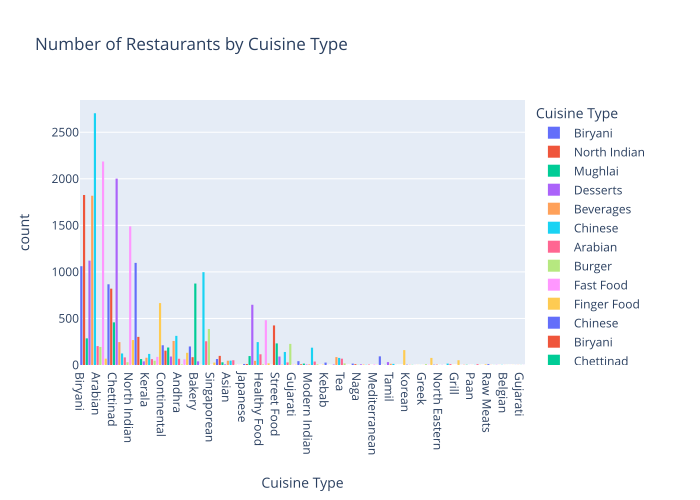

In [278]:
fig=px.histogram(cuisine_df,x='Cuisine',color='Cuisine',
                 title="Number of Restaurants by Cuisine Type",
                 labels={"Cuisine": "Cuisine Type"})
fig.show()

#2. How to categorize the restaurants in chennai with the rating type?

In [279]:
delivery_rating_df=zomato_ch_df['Delivery Rating'].value_counts().reset_index()
delivery_rating_df.rename(columns={'Delivery Rating':'Delivery Rating','Count':'Count'}, inplace=True) 
delivery_rating_df

,Delivery Rating,count
0,0.0,5851
1,3.9,1383
2,3.8,701
3,4.0,570
4,3.7,559
5,4.1,468
6,3.6,465
7,4.2,401
8,3.5,314
9,4.3,277


In [280]:
delivery_rating_type=[]
#delrating=[]    
def find_delrating_type(delivery_rating_df):

    
    delrating=delivery_rating_df['Delivery Rating']
    n_num=delivery_rating_df.shape[0]

    for i in range (n_num):
    
        if delrating[i]<3.0:
            delivery_rating_type.append("Very Poor")
        if delrating[i]>=3.0 and delrating[i]<3.5:
            delivery_rating_type.append("Poor")
        if delrating[i]>=3.5 and delrating[i]<4.0:
            delivery_rating_type.append("Good")
        if delrating[i]>=4.0 and delrating[i]<4.5:
            delivery_rating_type.append("Very Good")
        if delrating[i]>=4.5 and delrating[i]<=5.0:
            delivery_rating_type.append("Excellent")
    
    return delivery_rating_type
    

In [281]:
find_delrating_type(delivery_rating_df)

['Very Poor',
 'Good',
 'Good',
 'Very Good',
 'Good',
 'Very Good',
 'Good',
 'Very Good',
 'Good',
 'Very Good',
 'Poor',
 'Poor',
 'Very Good',
 'Poor',
 'Poor',
 'Poor',
 'Excellent',
 'Very Poor',
 'Very Poor',
 'Excellent',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Very Poor',
 'Excellent',
 'Very Poor',
 'Very Poor',
 'Very Poor']

In [282]:
delivery_rating_ty=pd.DataFrame(delivery_rating_type,columns=['Rating Category'])
delivery_rate_cate=pd.concat([delivery_rating_df,delivery_rating_ty],axis=1)
delivery_rate_cate=delivery_rate_cate.reindex(columns=['Delivery Rating','Rating Category','count'])
del_rate_cate_gp=delivery_rate_cate['Rating Category'].value_counts()
del_rate_cate_gp

Rating Category
Very Poor    15
Good          5
Very Good     5
Poor          5
Excellent     3
Name: count, dtype: int64

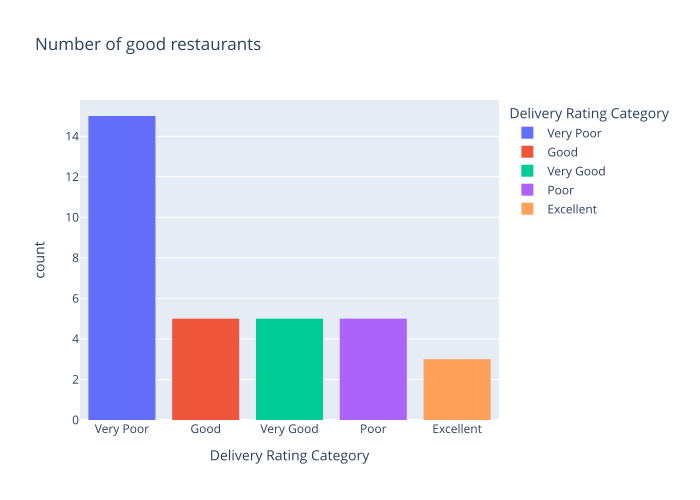

In [283]:
fig=px.histogram(delivery_rate_cate,x=delivery_rate_cate['Rating Category'],color='Rating Category',
                 title="Number of good restaurants",
                labels={"Rating Category":"Delivery Rating Category"})
fig.show()

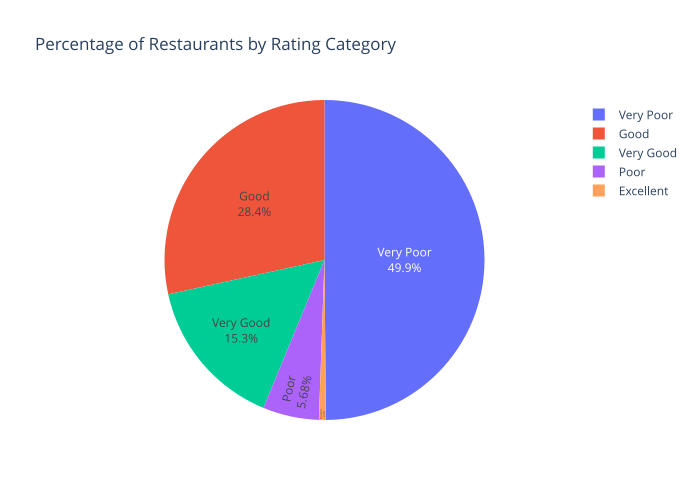

In [284]:
fig = px.pie(delivery_rate_cate, names='Rating Category', values='count', color='Rating Category', 
             title='Percentage of Restaurants by Rating Category').update_traces(textposition='inside', textinfo='percent+label')
fig.show() 

# 3. Which are the Top 10 highest rated Arabian Restaurant in Chennai?

In [285]:
arabian_df = zomato_ch_df[zomato_ch_df['Cuisine'].apply(lambda x: 'Arabian' in x)] 
arabian_df.sort_values(by='Dining Rating',ascending=False).head(10) 

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
116,AlMaza,Anna Nagar East,"[Arabian, Mughlai, North Indian, Biryani]","['Faluda', ' Rara Gosht', ' Buttermilk', ' Naa...",1000.0,4.6,764,4.2,881,"['Home Delivery', 'Indoor Seating', 'Table boo..."
315,Layalee,Ekkaduthangal,"[Arabian, BBQ, Seafood, Chinese, Continent...","['Fish', ' Faluda', ' Shawarma', ' Brownie', '...",700.0,4.4,586,4.1,143,"['Home Delivery', 'Table booking recommended',..."
64,Samco,Velachery,"[Arabian, Chinese, North Indian, Seafood]","['Biryani', ' Bbq Chicken', ' Faluda', ' Peppe...",800.0,4.3,1078,3.7,3862,"['Home Delivery', 'Valet Parking Available', '..."
8,Savoury Sea Shell,Anna Nagar East,"[Arabian, Chinese, North Indian, Lebanese, ...","['Shawarma', ' Chicken Grill', ' Brownie', ' S...",1400.0,4.2,2564,4.1,21700,"['Home Delivery', 'Indoor Seating', 'Card Upon..."
54,Fazari,Chromepet,[Arabian],"['Shawarma', ' Faluda', ' Brownie', ' Chicken ...",750.0,4.2,1288,3.8,19700,"['Home Delivery', 'Indoor Seating', 'Table boo..."
16,Arab Street,Ashok Nagar,"[Arabian, Biryani, Chinese, North Indian, ...","['Shawarma', ' Biryani', ' Chicken Grill', ' K...",800.0,4.1,1363,3.8,6228,"['Home Delivery', 'Valet Parking Available', '..."
427,Al Souk,Nungambakkam,"[Arabian, Lebanese, Middle Eastern, Egyptia...","['Baklava', ' Pita Bread', ' Hot Mezze Platter...",750.0,4.1,244,4.1,147,"['Home Delivery', 'Indoor Seating', 'Table boo..."
591,Iftar Corner,Perambur,"[Arabian, Asian, Chinese, North Indian]","['Noodle', ' Fried Rice']",600.0,4.0,329,4.0,7559,"['Home Delivery', 'Indoor Seating']"
8818,Savoury Sea Shell,Perungudi,"[Arabian, Kerala, Chinese, Biryani, North ...","['Shawarma', ' Chicken Grill', ' Brownie', ' F...",800.0,4.0,1223,4.0,13500,"['Home Delivery', 'Catering Available', 'Indoo..."
620,Palm Jumeira,Nungambakkam,"[Arabian, Chinese, North Indian]","['Biryani', ' Chicken Grill', ' Mutton Mandi',...",800.0,3.9,283,3.9,3848,"['Home Delivery', 'Indoor Seating', 'Wifi']"


In [174]:
# Keeps rows where 'target_value' exists in the list
#df_filtered = zomato_ch_df[zomato_ch_df['Cuisine'].apply(lambda x: 'Arabian' in x)]
#df_filtered

# 4 Which is the best Chinese Restaurant in Chennai?

In [286]:
chinese_df=zomato_ch_df[zomato_ch_df['Cuisine'].apply(lambda x: 'Chinese' in x)]
chinese_df.sort_values(by='Dining Rating',ascending=False).head(2)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
102,Mainland China,"Phoenix Market City, Velachery","[Chinese, Asian, Sushi, Japanese, Thai]","['Noodle', ' Dumplings', ' Momos', ' Hakka Noo...",1800.0,4.6,1498,4.2,335,"['Home Delivery', 'Mall Parking', 'Valet Parki..."
115,North East Kitchen,Egmore,"[Chinese, Konkan, Momos]","['Momos', ' Noodle', ' Pork Thali', ' Thukpa',...",450.0,4.5,705,4.3,1552,"['Home Delivery', 'Indoor Seating']"


# 5 Which places have the highest rated restaurant for each Cuisine Type in Chennai?

In [287]:
high_rated_df=cuisine_df[cuisine_df['Dining Rating']>=4.5]
high_rated_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
15,Welcome Hotel,Purasavakkam,South Indian,"['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094,0.0,Does not offer Delivery,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
15,Welcome Hotel,Purasavakkam,Desserts,"['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094,0.0,Does not offer Delivery,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
15,Welcome Hotel,Purasavakkam,Beverages,"['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094,0.0,Does not offer Delivery,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
24,Eating Circles,Alwarpet,South Indian,"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ...",250.0,4.7,782,4.2,2744,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
37,Shree Mithai,Chetpet,Mithai,"['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip...",300.0,4.6,1085,4.4,18600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
...,...,...,...,...,...,...,...,...,...,...
9363,Flower Drum,Adyar,Chinese,"['Momos', ' Noodle', ' Dimsum Platter', ' Sche...",800.0,4.5,617,4.3,819,"['Home Delivery', 'Wheelchair Accessible', 'Ve..."
9363,Flower Drum,Adyar,Thai,"['Momos', ' Noodle', ' Dimsum Platter', ' Sche...",800.0,4.5,617,4.3,819,"['Home Delivery', 'Wheelchair Accessible', 'Ve..."
9367,Cream Stone,Thuraipakkam,Desserts,"['Death By Chocolate', ' Chocolava', ' Tiramis...",350.0,4.5,683,4.2,4553,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
9367,Cream Stone,Thuraipakkam,Ice Cream,"['Death By Chocolate', ' Chocolava', ' Tiramis...",350.0,4.5,683,4.2,4553,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."


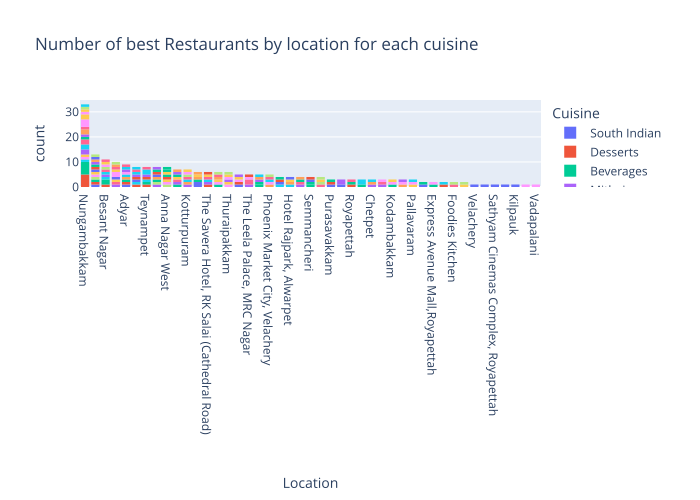

In [288]:
fig=px.histogram(high_rated_df, x='Location',color='Cuisine',
                 title='Number of best Restaurants by location for each cuisine').update_xaxes(categoryorder="total descending")
fig.show()

# 6 What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Chennai?

In [289]:
high_rating_price_df=high_rated_df.groupby(by=['Location','Cuisine'])['Price for 2'].mean().reset_index()
high_rating_price_df.head(25)

,Location,Cuisine,Price for 2
0,Adyar,Beverages,1800.0
1,Adyar,Chettinad,1800.0
2,Adyar,Desserts,1800.0
3,Adyar,Mughlai,1800.0
4,Adyar,Thai,800.0
5,Adyar,Chinese,800.0
6,Adyar,Ice Cream,200.0
7,Adyar,North Indian,1800.0
8,Adyar,South Indian,500.0
9,Alwarpet,American,1800.0


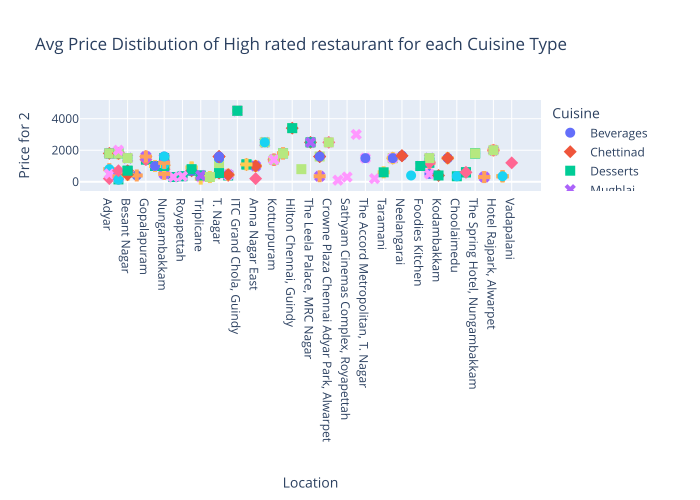

In [290]:
 fig = px.scatter(high_rating_price_df, x="Location", y="Price for 2", color="Cuisine", symbol="Cuisine",  
           title=' Avg Price Distibution of High rated restaurant for each Cuisine Type').update_traces(marker_size=10)
fig.show() 

# 7 Which areas have a large number of Arabian Restaurant Market?

In [291]:
arabian_df=zomato_ch_df[zomato_ch_df['Cuisine'].apply(lambda x: 'Arabian' in x)]
arabian_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
8,Savoury Sea Shell,Anna Nagar East,"[Arabian, Chinese, North Indian, Lebanese, ...","['Shawarma', ' Chicken Grill', ' Brownie', ' S...",1400.0,4.2,2564,4.1,21700,"['Home Delivery', 'Indoor Seating', 'Card Upon..."
16,Arab Street,Ashok Nagar,"[Arabian, Biryani, Chinese, North Indian, ...","['Shawarma', ' Biryani', ' Chicken Grill', ' K...",800.0,4.1,1363,3.8,6228,"['Home Delivery', 'Valet Parking Available', '..."
54,Fazari,Chromepet,[Arabian],"['Shawarma', ' Faluda', ' Brownie', ' Chicken ...",750.0,4.2,1288,3.8,19700,"['Home Delivery', 'Indoor Seating', 'Table boo..."
64,Samco,Velachery,"[Arabian, Chinese, North Indian, Seafood]","['Biryani', ' Bbq Chicken', ' Faluda', ' Peppe...",800.0,4.3,1078,3.7,3862,"['Home Delivery', 'Valet Parking Available', '..."
116,AlMaza,Anna Nagar East,"[Arabian, Mughlai, North Indian, Biryani]","['Faluda', ' Rara Gosht', ' Buttermilk', ' Naa...",1000.0,4.6,764,4.2,881,"['Home Delivery', 'Indoor Seating', 'Table boo..."
...,...,...,...,...,...,...,...,...,...,...
10273,Al Arabian Delights,Guindy,"[Arabian, Biryani, North Indian, Chinese]",NA,400.0,3.5,166,3.6,3694,"['Home Delivery', 'Indoor Seating']"
10274,Al Arabian Delights,Saidapet,"[Arabian, Biryani, North Indian, Chinese]",NA,400.0,0.0,0,3.9,3975,"['Home Delivery', 'Table booking recommended']"
10275,Al Arabian Delights,Medavakkam,"[Arabian, Biryani, North Indian, Chinese]",NA,400.0,3.3,32,3.6,1259,"['Home Delivery', 'Indoor Seating']"
10485,Oh My Shawarma,Ramapuram,"[Arabian, Lebanese]",['Mexican Shawarma'],350.0,3.9,111,4.0,501,"['Home Delivery', 'Free Parking', 'Indoor Seat..."


In [292]:
arabian_rest_df = arabian_df.groupby(by='Location').agg({'Location' : 'count', 'Price for 2' : 'mean'}).rename(columns={'Location':'Count of Restaurants'})
arabian_rest_df = arabian_rest_df.sort_values('Count of Restaurants', ascending=False) 
arabian_rest_df.head()

,Count of Restaurants,Price for 2
Location,,
Ambattur,6,341.666667
Perambur,6,375.000000
Porur,5,370.000000
Sholinganallur,4,400.000000
Perungudi,4,537.500000


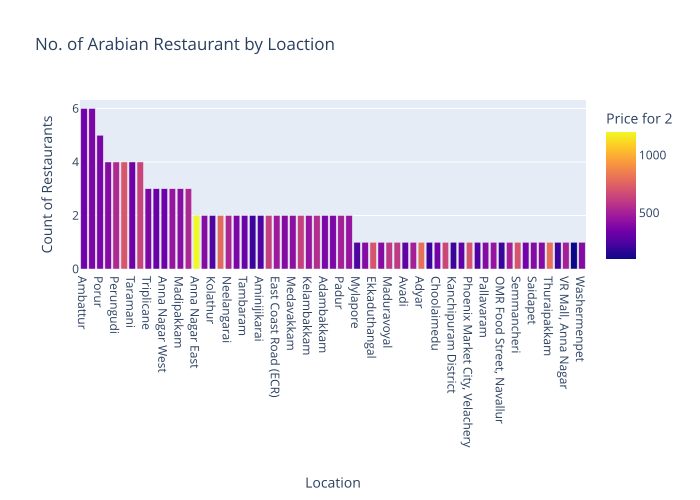

In [293]:
fig = px.bar(arabian_rest_df, color='Price for 2', y='Count of Restaurants', title= 'No. of Arabian Restaurant by Loaction')
fig.show() 

# 8 Is there a relation between Price and Rating by each Cuisine Type

In [294]:
price_rating_df=cuisine_df.groupby(['Cuisine','Dining Rating'])['Price for 2'].mean().reset_index()
price_rating_df

,Cuisine,Dining Rating,Price for 2
0,American,0.0,535.714286
1,American,2.0,300.000000
2,American,2.7,600.000000
3,American,2.8,866.666667
4,American,2.9,600.000000
...,...,...,...
1869,Tibetan,4.0,400.000000
1870,Tibetan,4.1,675.000000
1871,Tibetan,4.2,350.000000
1872,Turkish,4.3,500.000000


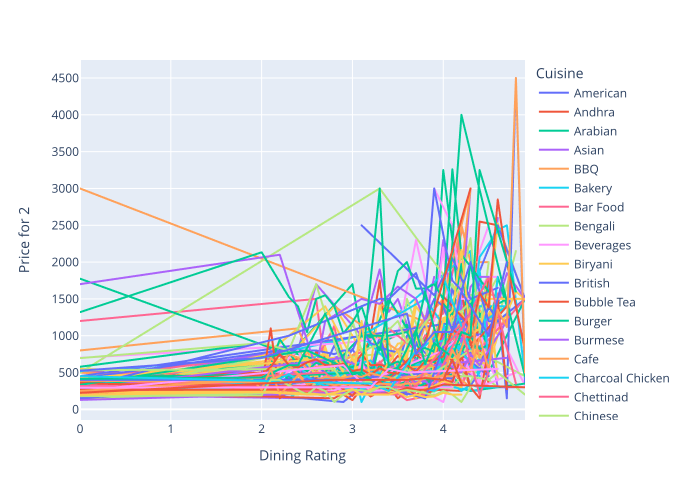

In [295]:
fig = px.line(price_rating_df, y="Price for 2", x="Dining Rating",color='Cuisine')
fig.show()

In [296]:
region_price_df=zomato_ch_df.groupby(['Location'])['Price for 2'].mean().reset_index()
region_price_df

,Location,Price for 2
0,InterContinental Chennai Mahabalipuram Resort...,1500.000000
1,Abhiramapuram,228.571429
2,"Abu Sarovar Portico, Egmore",1000.000000
3,Adambakkam,291.025641
4,Adyar,443.550000
...,...,...
263,"Vivira Mall, Navallur",500.000000
264,Washermenpet,291.735537
265,"WelcomHotel, RK Salai (Cathedral Road)",2075.000000
266,West Mambalam,267.846154


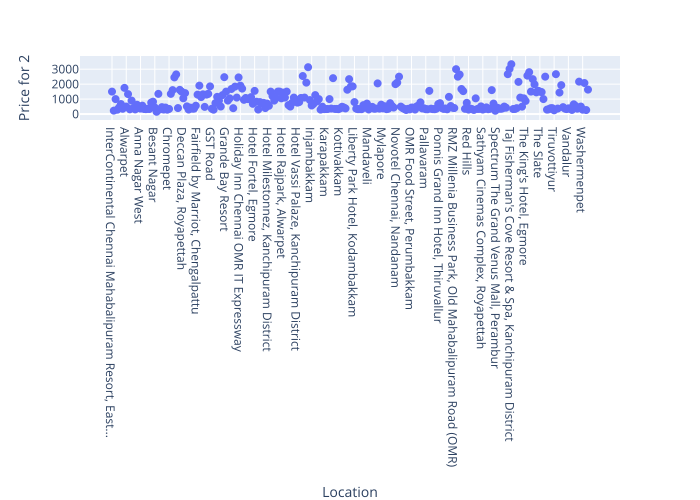

In [297]:
fig = px.scatter(region_price_df, x="Location", y="Price for 2").update_traces(marker_size=8) 
fig.show() 

# Find the list of Affordable Restaurants?
# The criteria for Affordable Restaurants would be:
# 1) Low Price 2) High Rated
# First step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.
# Let me explain:-The most expensive restaurant has an average meal cost= 6000. We'll try to stay economical and only pick the
# restaurants that are 1/4th of 6000


In [298]:
max_price = zomato_ch_df['Price for 2'].max() 
one_fourth_price = max_price/4 
one_fourth_price 

1250.0

In [299]:
# Finding the highest rated list of restaurants 
highrate_rest_df = zomato_ch_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location', 'Dining Rating']] 
highrate_rest_df = highrate_rest_df[highrate_rest_df['Dining Rating'] >= 4.5] 
highrate_rest_df.sort_values(by='Price for 2', inplace=True) 
highrate_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Dining Rating
108,Rayar's Mess,100.0,[South Indian],Mylapore,4.7
178,Royal Sandwich Shop,150.0,"[Fast Food, Desserts, Beverages]",Alwarpet,4.7
50,Andhikkadai,200.0,[South Indian],Velachery,4.6
154,Nair Mess,200.0,"[South Indian, Biryani]",Triplicane,4.5
320,Bombay Kulfi,200.0,[Ice Cream],Adyar,4.9
...,...,...,...,...,...
445,Dakshin - Crowne Plaza Chennai Adyar Park,2500.0,"[South Indian, Kerala, Andhra]","Crowne Plaza Chennai Adyar Park, Alwarpet",4.6
395,Southern Spice - Taj Coromandel,3000.0,[South Indian],"Taj Coromandel, Nungambakkam",4.7
229,Vasco's - Hilton Chennai,3400.0,"[North Indian, Continental, Asian]","Hilton Chennai, Guindy",4.6
443,Avartana - ITC Grand Chola,4500.0,"[South Indian, Chinese, Desserts]","ITC Grand Chola, Guindy",4.8


In [300]:
#Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restaurant
aff_rest_df = zomato_ch_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location']] 
aff_rest_df = aff_rest_df[aff_rest_df['Price for 2'] <= 1250] 
aff_rest_df.sort_values(by='Price for 2', inplace=True) 
aff_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location
4685,Soda Hub,40.0,[Beverages],"OMR Food Street, Navallur"
8355,Kaafemaa,50.0,[Beverages],Ambattur
6854,Planet Soda,50.0,"[Beverages, Juices]","OMR Food Street, Kandanchavadi"
7405,Indian Coffee House,50.0,"[Beverages, Juices]",Vepery
1448,Mamee Soup,60.0,[Healthy Food],West Mambalam
...,...,...,...,...
4671,Guinness'd Bar,1200.0,[Finger Food],"BKR Grand Hotel, T. Nagar"
644,Coastline Hide Out,1200.0,"[Continental, Beverages, BBQ, Chinese, Des...",Akkarai
3179,Lava Bar at Metro Grand Hotel,1200.0,[Bar Food],Arumbakkam
376,China Town,1200.0,"[Chinese, Seafood]",Gopalapuram


In [315]:
#Now, we'll merge the aff_rest_df with highrate_rest_df to obtain the intersection i.e the list of Affordable Restaurants !!

highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how='inner', on=['Name of Restaurant', 'Location']) 
highrate_aff_df = highrate_aff_df[['Name of Restaurant', 'Price for 2_x', 'Cuisine_x', 'Location']] 
highrate_aff_df.rename(columns={'Name of Restaurant':'Name of Restaurant', 'Price for 2_x':'Price for 2', 'Cuisine_x':'Cuisine',  
                                'Location':'Location'},inplace=True)

# Affordable Restaurants with low price and high rating  
 
highrate_aff_df 

,Name of Restaurant,Price for 2,Cuisine,Location
0,Rayar's Mess,100.0,[South Indian],Mylapore
1,Royal Sandwich Shop,150.0,"[Fast Food, Desserts, Beverages]",Alwarpet
2,Royal Sandwich Shop,150.0,"[Fast Food, Desserts, Beverages]",Alwarpet
3,Royal Sandwich Shop,150.0,"[Fast Food, Desserts, Beverages]",Alwarpet
4,Andhikkadai,200.0,[South Indian],Velachery
5,Nair Mess,200.0,"[South Indian, Biryani]",Triplicane
6,Bombay Kulfi,200.0,[Ice Cream],Anna Nagar East
7,Bombay Kulfi,200.0,[Ice Cream],Adyar
8,Eating Circles,250.0,[South Indian],Alwarpet
9,Shree Mithai,300.0,"[Mithai, Street Food, Fast Food]",Chetpet


#Find the list of most Reliable Restaurants?
#The criteria for most Reliable Restaurants would be:
#1) Low Price 2) High Rated 3) Large No. of Votes
#First step will be to find the restaurants with Votes greater than Mean of Votes

In [303]:
mean_votes = zomato_ch_df['Dining Rating Count'].mean() 
mean_votes 

np.float64(75.16165226063829)

In [304]:
#Finding list of restaurants that have Dining Rating Count greater than and equal to  Mean of Dining Rating Count 
 
mean_rest_df = zomato_ch_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location', 'Dining Rating Count']] 
mean_rest_df = mean_rest_df[mean_rest_df['Dining Rating Count'] > 75] 
mean_rest_df.sort_values(by='Dining Rating Count', inplace=True) 
mean_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Dining Rating Count
8788,SS Hyderabad Biryani,500.0,"[Biryani, North Indian, Chinese, Arabian]",Ambattur,76
948,On The Rocks - Crowne Plaza Chennai Adyar Park,4000.0,"[Continental, European]","Crowne Plaza Chennai Adyar Park, Alwarpet",76
1827,Arun Home Mess,200.0,[South Indian],Velachery,76
1179,Kulfi House,200.0,[Ice Cream],Alwarpet,76
1355,Auro Pizza,600.0,"[Pizza, Fast Food]",East Coast Road (ECR),76
...,...,...,...,...,...
9026,Copper Kitchen,1000.0,"[North Indian, Chinese, Chettinad, Seafood]",Porur,5073
9030,Paradise Biryani,800.0,"[Biryani, North Indian, Chinese]",Perungudi,5317
74,Onesta,600.0,"[Pizza, Italian, Fast Food, Beverages, Des...",Semmancheri,5407
9233,Barbeque Nation,1600.0,"[North Indian, Continental, Kebab, BBQ]",T. Nagar,5821


In [316]:
#These are the most reliable, highest rated and affordable restaurants:
#We obtain this dataframe by simply taking the intersection of highrate_aff_df & mean_rest_df
#This dataframe obtained below shows the restaurants whose:
#Cost is below 1250
#Rating is above 4.5
#Votes are above 75


reliable_rest_df = pd.merge(mean_rest_df, highrate_aff_df, how='inner', on=['Name of Restaurant', 'Location']) 
reliable_rest_df = reliable_rest_df[['Name of Restaurant', 'Price for 2_x', 'Cuisine_x','Location']] 
reliable_rest_df.rename(columns={'Name of Restaurant':'Restaurant Name', 'Price for 2_x':'Price for 2', 'Cuisine_x':'Cuisine',  
                                'Location':'Location', 'Cuisine_x':'Cuisine'},inplace=True)
reliable_rest_df

,Restaurant Name,Price for 2,Cuisine,Location
0,Shmoozie's Hand-Crafted Ice Creams,400.0,"[Ice Cream, Desserts]",Egmore
1,Kuuraku,1200.0,[Japanese],Vadapalani
2,Bombay Kulfi,200.0,[Ice Cream],Anna Nagar East
3,New Pattukottai Kamatchi Mess,550.0,"[Tamil, Chettinad]",T. Nagar
4,Wok Monk,1200.0,"[Asian, Chinese, Middle Eastern]",Anna Nagar West
5,Blind Ch3mistry,700.0,"[Cafe, Continental, Italian, Desserts, Bev...",Teynampet
6,Writer's Cafe,600.0,"[Cafe, American]",Taramani
7,Bombay Kulfi,200.0,[Ice Cream],Adyar
8,The Sandwich Shop,300.0,"[Sandwich, Fast Food, Beverages]",West Mambalam
9,Fruit Shop On Greams Road,350.0,"[Beverages, Fast Food, Healthy Food, Juices]",Thousand Lights
